In [1]:
import pandas as pd
from plotnine import aes
from plotnine import element_text
from plotnine import facet_wrap
from plotnine import geom_line
from plotnine import ggplot
from plotnine import scale_color_manual
from plotnine import theme
from plotnine import theme_minimal
from sqlalchemy import Integer
from sqlalchemy import create_engine
from sqlalchemy import func
from sqlalchemy.orm import Query

import src
from src.data.models import Channel
from src.data.models import Sentence
from src.data.models import Video

In [2]:
engine = create_engine(src.PS_ENGINE)

In [3]:
sentence_query = (
    Query(Sentence)
    .filter(Sentence.is_valid == True)
    .group_by(Sentence.video_id)
    .with_entities(
        Sentence.video_id,
        func.avg(Sentence.elite.cast(Integer)).label("elite"),
        func.avg(Sentence.pplcentr.cast(Integer)).label("pplcentr"),
        func.avg(Sentence.left.cast(Integer)).label("left"),
        func.avg(Sentence.right.cast(Integer)).label("right"),
    )
    .subquery()
)

query = (
    Query(Channel)
    .join(Video)
    .filter(
        Video.format == "videos",
        Video.is_valid == True,
    )
    .group_by(Channel.channel, Video.id)
    .join(sentence_query, Video.id == sentence_query.c.video_id)
    .with_entities(
        Channel.channel,
        Video.datetime_upload,
        func.avg(sentence_query.c.elite).label("elite"),
        func.avg(sentence_query.c.pplcentr).label("pplcentr"),
        func.avg(sentence_query.c.left).label("left"),
        func.avg(sentence_query.c.right).label("right"),
    )
)


with engine.connect() as conn:
    df = pd.read_sql(query.statement, conn)

df.channel = df.channel.replace({"BÜNDNIS 90/DIE GRÜNEN": "Grüne"})
df.datetime_upload = pd.to_datetime(df.datetime_upload)
df = df.sort_values(["channel", "datetime_upload"]).set_index("datetime_upload")

In [4]:
df_month = (
    df.groupby("channel")
    .resample("ME")
    .mean()
    .fillna(0)
    .rolling(window=12, min_periods=1)
    .mean(numeric_only=True)
    .reset_index()
)

In [5]:
df_long = pd.melt(
    df_month,
    id_vars=["channel", "datetime_upload"],
    var_name="variable",
    value_vars=[
        "elite",
        "pplcentr",
        "left",
        "right",
    ],
)

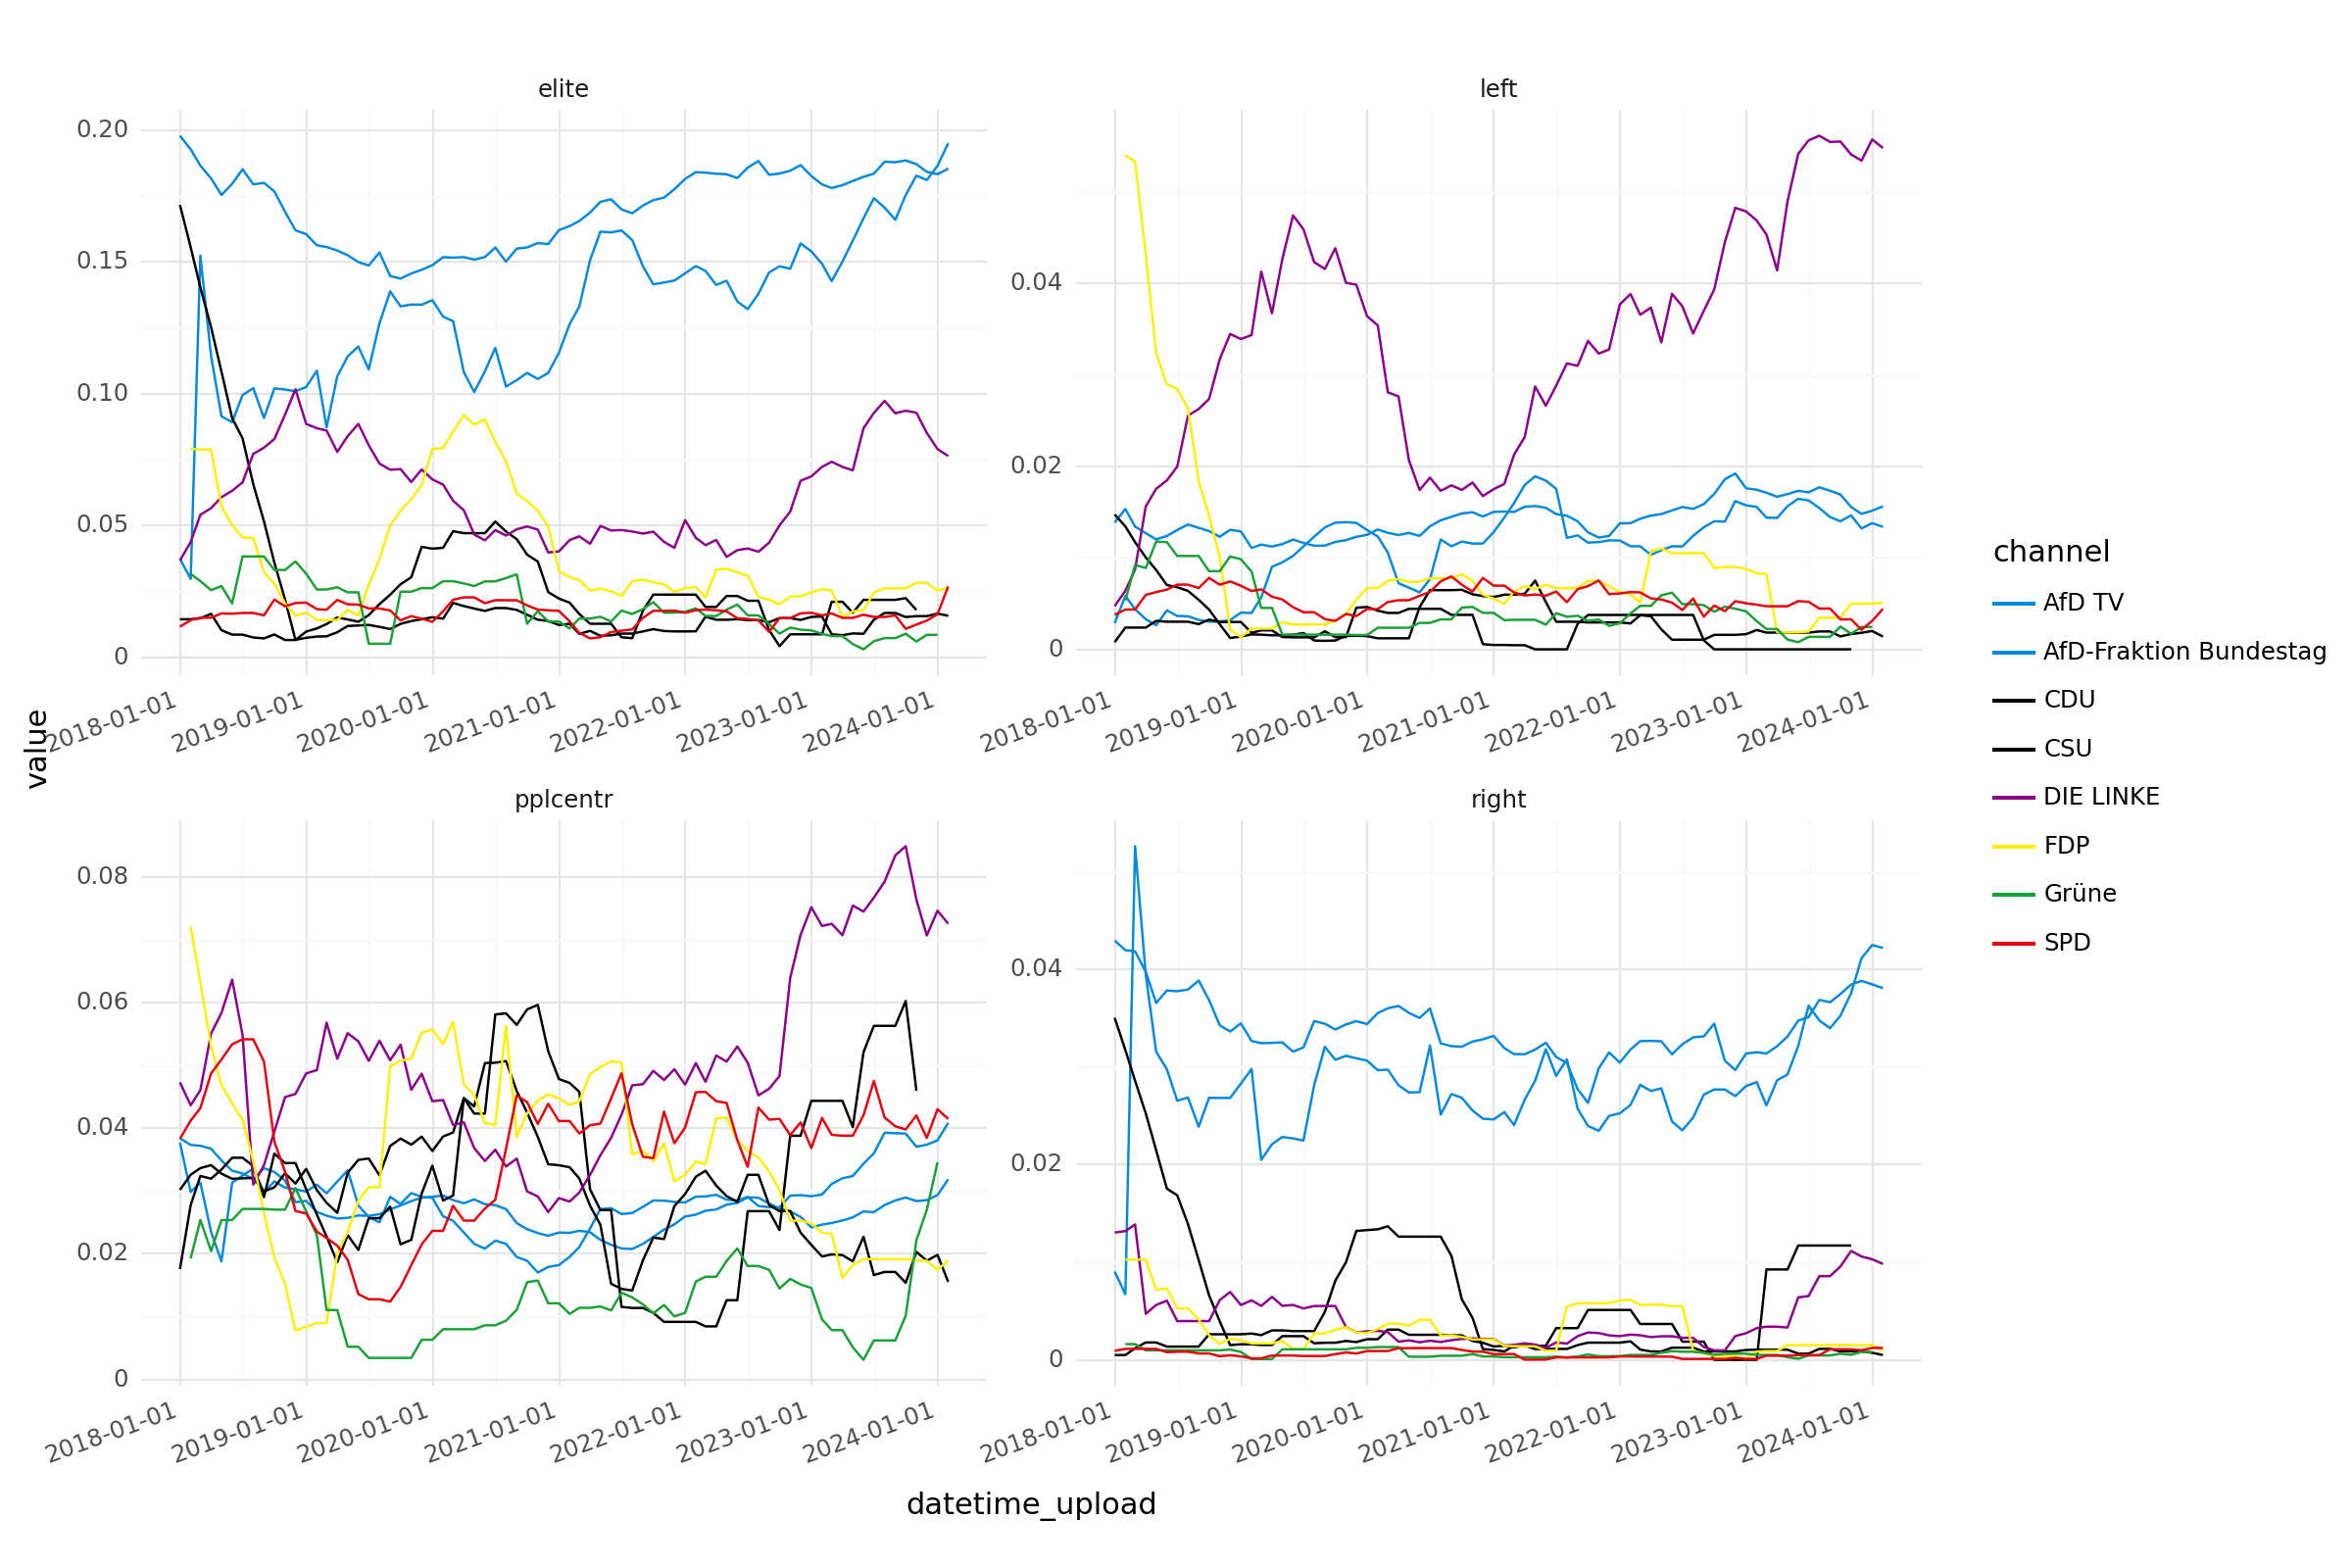

<Figure Size: (1200 x 800)>

In [6]:
(
    ggplot(df_long, mapping=(aes(x="datetime_upload", y="value", color="channel")))
    # + geom_smooth(span=.2, se=False)
    + geom_line()
    + scale_color_manual(src.colormap)
    + facet_wrap("~variable", scales="free", ncol=2)
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=20, hjust=1), figure_size=(12, 8))
)